<a href="https://colab.research.google.com/github/zaidkhan8241/Gold-Price-Prediction-using-Prophet/blob/main/Gold_Price_Prediction_using_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gold Price Prediction using Prophet

This notebook demonstrates how to use Facebook's Prophet library to forecast gold prices.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/gold-price-data")

print("Path to dataset files:", path)

100%|██████████| 41.9k/41.9k [00:00<00:00, 44.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/gold-price-data/versions/1


## 1. Data Loading

First, we download the dataset from Kaggle using `kagglehub` and inspect the directory to find the correct CSV file.

In [3]:
import os
print(os.listdir(path))

['gld_price_data.csv']


We list the contents of the downloaded directory to identify the exact name of the CSV file containing the gold price data. This helps prevent `FileNotFoundError`.

In [4]:
!pip install prophet

## 2. Setup Prophet Library

We install and import the necessary libraries for our time series forecasting task using Prophet.

In [5]:
import pandas as pd
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

## 3. Data Preprocessing

We load the gold price data into a Pandas DataFrame. Prophet requires the time series data to have specific column names: `ds` for the timestamp and `y` for the value to be forecasted. We'll rename the 'Date' and 'GLD' columns accordingly.

In [6]:
df = pd.read_csv(f'{path}/gld_price_data.csv', index_col='Date', parse_dates=True)
df.head()

,SPX,GLD,USO,SLV,EUR/USD
Date,,,,,
2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


After loading, we check the shape of the DataFrame to understand its dimensions (number of rows and columns).

In [7]:
df.shape

(2290, 5)

In [8]:
df = df.reset_index()
df = df[['Date', 'GLD']]
df.columns = ['ds', 'y']
df.head()

,ds,y
0,2008-01-02,84.860001
1,2008-01-03,85.570000
2,2008-01-04,85.129997
3,2008-01-07,84.769997
4,2008-01-08,86.779999


## 4. Initial Data Visualization

Let's visualize the gold price over time to observe any trends, seasonality, or anomalies before applying the forecasting model.

<Axes: xlabel='ds'>

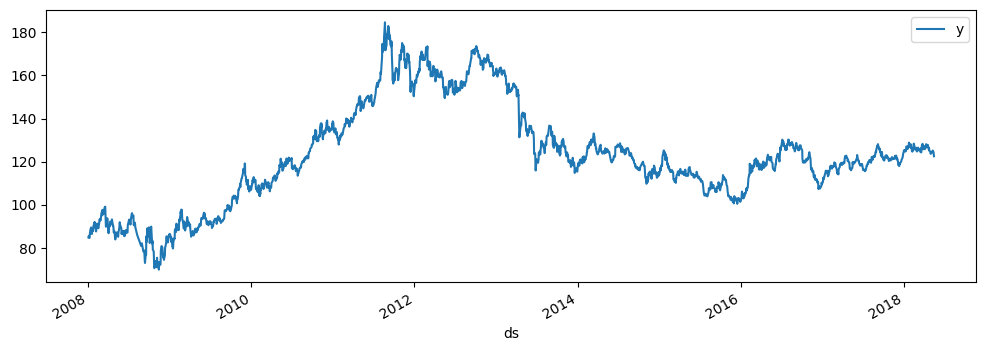

In [9]:
df.plot(x='ds', y='y', figsize=(12,4))

## 5. Train-Test Split

To evaluate our model's performance, we split the data into training and testing sets. We use the first 90% of the data for training and the remaining 10% for testing.

In [10]:
split = int(len(df) * 0.90)

train = df.iloc[:split]
test = df.iloc[split:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (2061, 2)
Test shape: (229, 2)


## 6. Prophet Model Training and Forecasting

We initialize the Prophet model, fit it to our training data, and then make predictions for the future period covered by our test set. Prophet automatically handles trend, seasonality, and holidays.

In [12]:
m = Prophet()
m.fit(train)
future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## 7. Inspecting Forecast Results

Let's view the first and last few rows of the `forecast` DataFrame to understand its structure, which includes the predicted values (`yhat`) and their uncertainty intervals (`yhat_lower`, `yhat_upper`). We also compare the tail of the `test` dataset with the tail of the forecast.

In [13]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2008-01-02,91.402140,82.296782,95.141853,91.402140,91.402140,-2.321982,-2.321982,-2.321982,1.406771,1.406771,1.406771,-3.728753,-3.728753,-3.728753,0.0,0.0,0.0,89.080158
1,2008-01-03,91.364751,82.963187,95.790795,91.364751,91.364751,-2.236715,-2.236715,-2.236715,1.344823,1.344823,1.344823,-3.581538,-3.581538,-3.581538,0.0,0.0,0.0,89.128036
2,2008-01-04,91.327362,82.626342,96.105751,91.327362,91.327362,-2.063240,-2.063240,-2.063240,1.357818,1.357818,1.357818,-3.421058,-3.421058,-3.421058,0.0,0.0,0.0,89.264122
3,2008-01-07,91.215195,83.791490,96.860025,91.215195,91.215195,-1.417254,-1.417254,-1.417254,1.471520,1.471520,1.471520,-2.888774,-2.888774,-2.888774,0.0,0.0,0.0,89.797941
4,2008-01-08,91.177806,83.612572,96.862018,91.177806,91.177806,-1.312490,-1.312490,-1.312490,1.391683,1.391683,1.391683,-2.704173,-2.704173,-2.704173,0.0,0.0,0.0,89.865316


The `yhat` column represents the predicted gold prices, while `yhat_lower` and `yhat_upper` provide the lower and upper bounds of the credible interval for the predictions.

In [14]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2285,2017-12-07,123.077049,112.886022,133.286373
2286,2017-12-08,122.949525,113.808219,133.238077
2287,2017-12-09,117.951821,108.594852,128.801291
2288,2017-12-10,117.786857,108.062199,127.807614
2289,2017-12-11,122.570341,112.716196,132.977031


Comparing the tail of the `test` dataset with the forecast helps us visually inspect how well the model's predictions align with actual values in the out-of-sample period.

In [15]:
test.tail()

,ds,y
2285,2018-05-08,124.589996
2286,2018-05-09,124.330002
2287,2018-05-10,125.180000
2288,2018-05-14,124.489998
2289,2018-05-16,122.543800


## 8. Visualizing the Forecast

Prophet provides convenient plotting functions to visualize the forecast and its individual components (trend, weekly seasonality, yearly seasonality).

In [16]:
plot_plotly(m, forecast)

This plot shows the actual historical data (black dots), the model's overall forecast (blue line), and the uncertainty intervals (light blue shaded region).

In [17]:
plot_components_plotly(m, forecast)

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



These plots break down the forecast into its additive components: overall trend, yearly seasonality, and weekly seasonality, providing insights into the patterns learned by the model.

In [18]:
from statsmodels.tools.eval_measures import rmse

## 9. Model Evaluation

Finally, we evaluate the model's performance on the test set using a common metric like Root Mean Squared Error (RMSE).

In [19]:
predictions = forecast.iloc[split:]['yhat']

We extract the predicted values (`yhat`) corresponding to the test set period from the `forecast` DataFrame.

In [20]:
print("Root Mean Squared Error between actual and  predicted values: ",rmse(predictions,test['y']))
print("Mean Value of Test Dataset:", test['y'].mean())

Root Mean Squared Error between actual and  predicted values:  3.8552575719773308
Mean Value of Test Dataset: 122.80075914847163


## 10. Forecasting Future Gold Prices

Now, we will use the trained Prophet model to forecast gold prices for a future period. We will extend the `future` DataFrame and generate predictions.

The RMSE quantifies the average magnitude of the errors between predicted and actual values. A lower RMSE indicates a better fit. Comparing it to the mean value of the test dataset gives context to the error magnitude.

In [28]:
future = m.make_future_dataframe(periods=730)
forecast = m.predict(future)
future_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(730)
future_forecast

,ds,yhat,yhat_lower,yhat_upper
2061,2017-04-27,121.038615,114.889700,127.197155
2062,2017-04-28,121.108801,114.686387,127.490620
2063,2017-04-29,116.315625,109.981366,122.470790
2064,2017-04-30,116.359058,110.271360,123.154212
2065,2017-05-01,121.351727,114.983310,127.666595
...,...,...,...,...
2786,2019-04-22,132.413369,82.715120,181.808300
2787,2019-04-23,132.397330,82.556243,182.848133
2788,2019-04-24,132.478669,81.027148,182.108822
2789,2019-04-25,132.483813,82.137702,183.165152


We extract the relevant columns (`ds` for date and `yhat` for predicted value) from the `forecast` DataFrame and rename them for clarity. Here, we specifically look at the last 30 days of the forecast.

In [29]:
future_forecast = forecast[['ds', 'yhat']].tail(30)
future_forecast.columns = ['Date', 'Predicted Gold Price']
future_forecast

,Date,Predicted Gold Price
2761,2019-03-28,132.637491
2762,2019-03-29,132.623037
2763,2019-03-30,127.746796
2764,2019-03-31,127.710133
2765,2019-04-01,132.627090
2766,2019-04-02,132.502724
2767,2019-04-03,132.470371
2768,2019-04-04,132.358990
2769,2019-04-05,132.321625
2770,2019-04-06,127.427389


## 11. Visualizing the Future Forecast

Finally, we visualize the full forecast, including the historical data and the predicted future gold prices, along with their uncertainty intervals.

In [30]:
plot_plotly(m, forecast)